In [1]:
from mpi4py import MPI
import coqui

import numpy as np
from scipy.constants import physical_constants
HARTREE_EV = physical_constants['Hartree energy in eV'][0]

import matplotlib.pyplot as plt

# Create CoQui MPI handler and set logging verbosity in the beginning
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-14 09:24:44.005704


# Constrained random phase approximation (cRPA)

<figure style="text-align: center;">
 <img src="../../images/svo_crpa_cartoon_ver2.png" alt="cRPA svo" width="40%">
 <figcaption><em>Figure&nbsp;1:</em> Different types of screening processes, involving transitions between the target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$.</figcaption>
</figure>

In this notebook, we compute effective Coulomb interactions for a chosen Hilbert subspace using the constrained random phase approximation (cRPA).

In cRPA, the full Hilbert space $\mathcal{B}$ is partitioned into a target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$ which contains all remaining degrees of freedom. This partitioning gives rise to three types of screening processes, illustrated in Figure 1: (1) transitions between $\mathcal{C}$ and $\mathcal{B}\backslash\mathcal{C}$, (2) transitions within the environment $\mathcal{B}\backslash\mathcal{C}$, and (3) transitions within the subspace $\mathcal{C}$.

The cRPA screened interaction

$$
U_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_{n}) = V(\mathbf{q}) + V(\mathbf{q})\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n)W(\mathbf{q}, i\Omega_{n})
$$

is defined via a *partially* screened polarization $\Pi_{\mathrm{cRPA}}$ in which screening processes internal to $\mathcal{C}$ are excluded:

$$
\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n) = \Pi_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n) - \Pi^{(3)}_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n).
$$

Physically, $U_{\mathrm{cRPA}}$ can be viewed as an effective bare Coulomb interaction for the subspace $\mathcal{C}$. 
When constructing low-energy models restricted to $\mathcal{C}$, removing the intra-subspace screening ensures that these processes are not double-counted, since they will be treated explicitly when solving the effective model. 

**What's covered in this notebook**
1. How to compute cRPA screened interactions

2. How to manipulate dynamic correlation function via `IAFT` class

2. How to extract Hubbard–Kanamori parameterization from cRPA results

3. How the Wannier window affects static and dynamic effective interactions


First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `svo_222/` (QE and Wannier90 outputs for 2x2x2 SrVO$_3$)

In [2]:
%%bash
python copy_notebook_inputs.py

Copied: data/qe_inputs/svo/222 -> svo_222
Notebook inputs are ready.


### Section 1: cRPA

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_crpa.png" alt="cRPA workflow in CoQuí" width="60%">
 <figcaption>cRPA workflow in CoQuí.</figcaption>
</figure>

As illustrated in Figure 2, the cRPA workflow in CoQuí closely parallels the GW workflow. Both calculations start from a second-quantized interacting Hamiltonian compressed in the THC representation and take advantages of efficient imaginary-axis Fourier transform using the DLR basis. The target subspace $\mathcal{C}$ is defined using maximally localized Wannier functions (MLWFs).

Starting from an interacting Hamiltonian stored in a `ThcCoulomb` instance, cRPA can be performed through a single call to  `downfold_coulomb`, which carries out the downfolding of the Coulomb interaction into the $\mathcal{C}$ subspace defined by the MLWFs:

>```python
>coqui.downfold_coulomb(h_int: ThcCoulomb, params: dict) -> Tuple[Vloc, Uloc_w]
>```

Function inputs:
- `h_int`: `ThcCoulomb` instance for the Coulomb Hamiltonian

- `params`: dictionary of cRPA parameters. Key parameters include:

    - `outdir` (default: `"."`): output directory

    - `prefix` (required): checkpoint prefix

    - `wannier_file` (required): MLWF HDF5 archive that defines the target subspace $\mathcal{C}$.

    - `screen_type` (required): screening prescription that defines the irreducible polarizability $\Pi(\mathbf{q},i\Omega_{n})$ used to compute the screened interaction $W$. Available options include: `"crpa"`, `"rpa"`, etc.

    - `greens_func_source` (required): determines whether polarization is evaluated using mean-field or interacting electronic structure:
        - `"mf"`: uses the mean-field Green's function $G_0$ from the underlying `Mf` object. If no checkpoint is available, the mean-field Green's function is generated on the fly using the supplied `beta` parameter.

        - `"scf"`: uses the interacting Green's function $G$ obtained from a self-consistent MBPT calculation read from an exisiting checkpoint

    - `beta` (default: 1000): inverse temperature (in a.u.$^{-1}$). This parameter is used only when there is no checkpoint to read the Green's function from.

Returned outputs:
- `Vloc`: bare local tensor $V_{abcd}$ in the MLWF basis, with shape $(N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

- `Uloc_w`: dynamic screened interaction $U_{abcd}(i\Omega_n)$ in the MLWF basis, with shape $(N^{+}_{\mathrm{freq}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

Here, $N_{\mathrm{wann}}$ denotes the number of MLWFs in the target subspace. The frequency dimension $N^{+}_{\mathrm{freq}}$ contains only the *positive* bosonic Matsubara frequencies on the DLR mesh. Since the screened interaction satisfies the particle-hole symmetry relation
$$
U(-i\Omega_{n}) = U(i\Omega_{n})
$$
the negative-frequency components are redundant and therefore are not stored explicitly.

> The returned downfolded interactions are also stored in the checkpoint `{outdir}/{prefix}.mbpt.h5` under the group `scf/iter{X}/downfolded_model/` where `X` is the iteration number of the self-consistent MBPT calculation from which the Green's function is read.


#### 🔹 Example: cRPA screened interaction for V $t_{2g}$ on SrVO$_3$

In [3]:
nbnd = 100
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_{nbnd}", 
    "wannier_file": "svo_222/mlwf/svo.mlwf.h5", 
}
Vloc, Uloc_iw = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 100
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 144.0 a.u. | FFT mesh = (39,39,39), Number of PWs = 31463
  Threshold                    = 0.001

**************************

Check the output log and identify the orbital-averaged Coulomb interactions.

 - What are the orbital-averaged *bare* and *static screened* interactions?

 - Are the computed values consistent with those reported in literature?

Special care should be taken for the screened interaction, since it depends sensitively on both the number of bands (`nbnd`) and the k-point mesh used in the polarization calculation. Convergence with respect to these parameters should always be checked carefully.

By contrast, the *bare* interaction is determined solely by the spatial localization of MLWF and is independent of the number of unoccupied bands included in the polarization. It has only a mild dependence on the size of the k-mesh through the Wannierization procedure. 

 > Note: Reference cRPA values [[1]](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.86.165105): bare $U\sim16$ eV, screened $U(0)\sim3.5$ eV, and $J\sim0.6$ eV.

 > Note: Small imaginary components may appear if MLWFs are not strictly real, often due to limited k-mesh size in Wannierization.


### Section 2: Manipulate dynamical correlation functions on the imaginary axis

Post-processing of correlation functions is an essential part of many-body simulations. 

Common tasks include, but not limited to, (i) inspecting the frequency dependence of quantities such as screened interactions or self-energies, (ii) transforming between imaginary-time and Matsubara-frequency representations for analysis, (iii) evaluating functions on meshes different from the native DLR grid, and (iV) analytical continuation to the real axis.

In CoQuí, the output correlation functions are always on imaginary axis sampled on DLR meshes. For flexible analysis and visualization, being able to manipulate these objects on the imaginary axis directly in is therefore very useful.

CoQuí provides the `IAFT` class for this purpose. `IAFT` encapsulates the DLR basis and offers utilities to:
- generate fermionic/bosonic $\tau$ and $i\omega_n$ meshes,

- perform Fourier transforms between $\tau$ and $i\omega_n$,

- interpolate correlation functions to arbitrary points on the imaginary axis.

Constructor:
>```python
>IAFT.from_coqui_chkpt(chkpt_h5: str) -> IAFT
>```

- `chkpt_h5` (required): CoQuí checkpoint file.

The constructor reads DLR basis metadata from the checkpoint and returns an initialized `IAFT` object ready for transformations and mesh generation.

Use Python help to inspect the available APIs and docstrings:
>```python
>help(IAFT)
>```


#### 🔹 Example: IAFT basics and visualize cRPA freuqnecy dependence 

Using the cRPA screened interaction computed in the previous section, this example demonstrates how to initialize the `IAFT` class from a CoQuí checkpoint and illustrates several common usages of its methods,including mesh generation, interpolation, and transformations on the imaginary axis.

In the final part of the example, we plot the frequency dependence of representative matrix elements of the cRPA screened interaction:

$$
U_{\mathrm{cRPA}} = V_{abcd} + U_{abcd}(i\Omega_n)
$$

where $V_{abcd}$ is the bare interaction and $U_{abcd}(i\Omega_n)$ is the dynamical screening contribution returned from `downfold_coulomb`. 

> Note: CoQui inputs and outputs are given in atomic units; Use the `HARTREE_EV` constant to convert interactions from Hartree to eV. 

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
Fermionic Matsubara indices: [   1    3    5    7    9   11   13   15   19   23   27   33   39   47
   53   71   85   99  137  183  213  249  335  481  585  745 1031 1421
 1969 3133 6631]
Fermionic Matsubara indices in physical notation: [   0    1    2    3    4    5    6    7    9   11   13   16   19   23
   26   35   42   49   68   91  106  124  167  240  292  372  515  710
  984 1566 3315]
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 4.128302429370114 a.u.
  Lambda                 = 4128.302429370115
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 62, 62, 62, 63



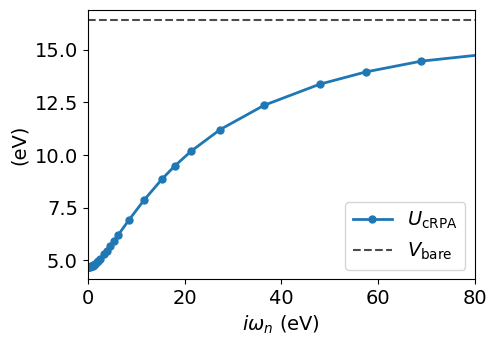

In [3]:
from coqui import IAFT

# --- Initialization ---
iaft = IAFT.from_coqui_chkpt("crpa_100.mbpt.h5")

# --- Mesh points ---
# tau points go from [0, beta]
tau_mesh_fermion, tau_mesh_boson = iaft.tau_mesh(stats='fermion'), iaft.tau_mesh(stats='boson')
# Matsubara frequency points are odd (fermion) or even (boson) integers 
# **NOTE** the physical Matsubara frequency should be multiplied by 2*pi/beta
wn_mesh = iaft.wn_mesh(stats='fermion', positive_only=True)
print(f"Fermionic Matsubara indices: {wn_mesh}")
wn_mesh_phys = iaft.wn_mesh(stats='fermion', phys_notation=True, positive_only=True)
print(f"Fermionic Matsubara indices in physical notation: {wn_mesh_phys}")

# --- Fourier transform ---
Uloc_t = iaft.w_to_tau(Uloc_iw, stats='boson', ph_sym=True)

# --- Interpolation ---
Uloc_zero_beta = iaft.tau_interpolate(Uloc_t, [0, iaft.beta], stats='boson', ph_sym=True)

# --- Plotting frequency dependence of screened interaction ---
iw_mesh_pos = iaft.wn_mesh(stats='b', positive_only=True) * np.pi / iaft.beta

fig, ax = plt.subplots(1, figsize=(5,3.5), dpi=100)
ax.plot(iw_mesh_pos*HARTREE_EV, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='$U_{\mathrm{cRPA}}$')
ax.axhline(y=Vloc[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="--", linewidth=1.5, alpha=0.7, label='$V_{\mathrm{bare}}$')
ax.set_xlim(0, 80)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('$i\omega_{n}$ (eV)', fontsize=14)
ax.set_ylabel('(eV)', fontsize=14)
ax.legend(fontsize=14)
plt.show()

#### 🔹 Example: Analytic continuation to real frequency

As seen in the previous example, correlation functions on the imaginary axis are typically smooth and numerically well behaved, which makes calculations on the imaginary axis particularly convenient for many-body simulations. On the other hand, most experimental observables probe dynamical response functions on the real-frequency axis. 

Obtaining real-frequency quantities therefore requires analytic continuation from the imaginary axis to $\omega + i0^+$. This is a notoriously ill-posed numerical problem in which small numerical noise on the imaginary axis can lead to large uncertainties in the resulting real-frequency spectra.

CoQuí provides several continuation utilities in `coqui.post_proc`:
- `pade`: native CoQuí Padé implementation

- `aaa_adapol`: robust rational approximation with adaptive pole selection via [adapol](https://github.com/flatironinstitute/adapol) Python package

- `minipole`: compact pole expansion constrained by moments/symmetry via [mini_pole](https://github.com/Green-Phys/MiniPole) package. 

In this example, we apply all three different methods to the same matrix element $U_{0000}(i\Omega_n)$ and compare both $-\operatorname{Im}U(\omega)$ and $\operatorname{Re}U(\omega)$.

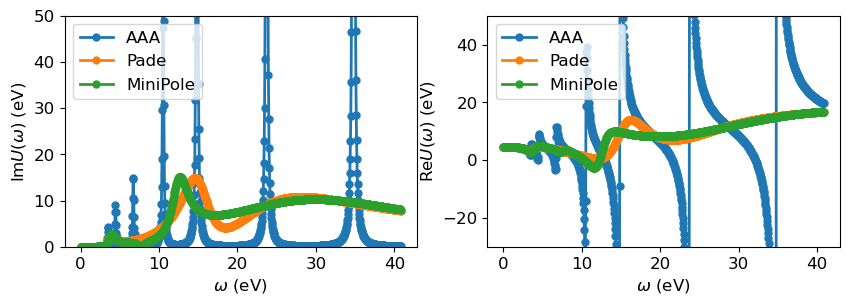

In [4]:
Uw_aaa, w_mesh_aaa = coqui.post_proc.aaa_adapol(Uloc_iw[:,0,0,0,0], iaft, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, Nfit=40, ph_sym=True)
Ufit = coqui.post_proc.aaa_adapol_imag(Uloc_iw[:,0,0,0,0], iaft, stats='boson', Nfit=60, ph_sym=True)
Uw_pade, w_mesh_pade = coqui.post_proc.pade(Ufit, iaft, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, Nfit=100, eta=None, ph_sym=True)
Uw_minipole, w_mesh_minipole = coqui.post_proc.minipole(Ufit, iaft, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, tol=1e-12, eta=None, ph_sym=True)

fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].plot(w_mesh_aaa.real * HARTREE_EV, -Uw_aaa.imag * HARTREE_EV,
            linewidth=2, marker='o', markersize=5, label='AAA')
ax[0].plot(w_mesh_pade.real * HARTREE_EV, -Uw_pade.imag * HARTREE_EV,
            linewidth=2, marker='o', markersize=5, label='Pade')
ax[0].plot(w_mesh_minipole.real * HARTREE_EV, -Uw_minipole.imag * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='MiniPole')
ax[0].set_ylim(0, 50)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('$\omega$ (eV)', fontsize=12)
ax[0].set_ylabel('Im$U(\omega)$ (eV)', fontsize=12)
ax[0].legend(fontsize=12)

ax[1].plot(w_mesh_aaa.real * HARTREE_EV, (Vloc[0,0,0,0]+Uw_aaa).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='AAA')
ax[1].plot(w_mesh_pade.real * HARTREE_EV, (Vloc[0,0,0,0]+Uw_pade).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='Pade')
ax[1].plot(w_mesh_minipole.real * HARTREE_EV, (Vloc[0,0,0,0]+Uw_minipole).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='MiniPole')   
ax[1].set_ylim(-30, 50)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[1].set_xlabel('$\omega$ (eV)', fontsize=12)
ax[1].set_ylabel('Re$U(\omega)$ (eV)', fontsize=12)
ax[1].legend(fontsize=12)

#### 🔹 Post-processing / interpretation: extract Hubbard–Kanamori parameters

The local interaction from `downfold_coulomb` is a four-index tensor $U_{abcd}(i\Omega_n)$ in the MLWF basis. For many applications, this is reduced to Hubbard–Kanamori parameters: $U$, $U'$, and Hund couplings.

Tasks:
1. Build static tensor from bare $V$ and screened part at $\Omega_n=0$.
2. Extract $U$, $U'$, $J$ from $U_{abcd}(0)$:
$$
U = \langle U_{iiii}(0)\rangle_i,\quad
U' = \langle U_{iijj}(0)\rangle_{i\neq j},\quad
J_{\text{spin-flip}} = \langle U_{ijji}(0)\rangle_{i\neq j},\quad
J_{\text{pair-hopping}} = \langle U_{ijij}(0)\rangle_{i\neq j}.
$$
3. Check rotational-invariance relations:
$$
U' \approx U - 2J,\qquad
J_{\text{spin-flip}} = J_{\text{pair-hopping}} = J.
$$
4. Compare with CoQuí log summaries and literature values.


In [6]:
# Your task: Write a function to return orbital-average parametrization of the Hubbard Kanamori model
def orb_avg_coulomb(V_abcd):
    norb = V_abcd.shape[0]

    U = 0
    for i in range(norb):
        U += V_abcd[i,i,i,i]
    U /= norb

    Up = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                Up += V_abcd[i,i,j,j]
    Up /= (norb * (norb-1) ) / 2

    J_pair = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_pair += V_abcd[i,j,i,j]
    J_pair /= (norb * (norb-1) ) / 2

    J_spin = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_spin += V_abcd[i,j,j,i]
    J_spin /= (norb * (norb-1) ) / 2

    return U, Up, J_pair, J_spin

In [7]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc_iw[0].real * HARTREE_EV)
print("Small window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}\n")

Small window
-------------
Bare Interactions
  - Intra-orbital: 16.39294746691176
  - Inter-orbital: 15.028426437127182
  - Pair hopping: 0.6477224564814777
  - Spin flip:    0.6477224564814777
Screened Interactions
  - Intra-orbital: 4.674065199603572
  - Inter-orbital: 3.585983502304451
  - Pair hopping: 0.52081315612938
  - Spin flip:    0.52081315612938



### Section 3: Effective Coulomb interactions for different models

<figure style="text-align: center;">
 <img src="../../images/svo_crpa_cartoon.png" alt="cRPA svo" width="30%">
 <figcaption><em>Figure&nbsp;3:</em> Energy window of the $dp$ model for SrVO$_{3}$.</figcaption>
</figure>

This example illustrates how cRPA interactions depend on the choice of low-energy model. 

For the same SrVO$_3$ material, we now consider a larger low-energy model consisting of V $3d$ and O $2p$ states using the MLWF projectors provided in `svo_222/mlwf_dp/svo_dp.mlwf.h5`. 

The corresponding MLWFs are constructed with an energy window that covers both the red and blue bands shown in Figure 3. Due to the larger energy window, the resulting V $t_{2g}$ Wannier functions become more localized compared to those in the $t_{2g}$-only model considered in the previous example. 

Changing from a $t_{2g}$-only model to a larger $dp$ model affects the cRPA interaction in two ways:
- The spatial profile of the MLWFs changes, which affects the bare Coulomb matrix elements $V_{abcd}$.

- The set of polarization processes excluded from the screening changes, since a larger target subspace removes more transitions from $\Pi_{\mathrm{cRPA}}$.

Tasks:
1. Perform a cRPA calculation for the dp model using the MLWF archive `svo_222/mlwf_dp/svo_dp.mlwf.h5`. 

2. Extract the bare and static screened interaction for the V $3d$ states, and plot $U_{\mathrm{cRPA}}(i\Omega_n)$ along the imaginary axis.

3. Analytically continue $U_{\mathrm{cRPA}(i\Omega_{n})}$ to the real-frequency axis and compare its spectrum with that obtained from the $t_{2g}$-only model. In particular, examine how the low-energy screening features change when moving from the $t_{2g}$-only model to the larger $dp$ model.

Checklist:
- The bare interactions for the V $t_{2g}$ orbitals should be larger in the $dp$ model, consistent with the more localized Wannier basis. 

- The bare interactions for the V $t_{2g}$ orbitals should be larger in the $dp$ model, consistent with the more localized Wannier basis. 

- In the real-frequency spectrum $-\operatorname{Im}U_{\mathrm{cRPA}}(\omega)$, the low-energy screening features should be reduced in the $dp$ model, consistent with the larger set of polarization processes excluded from $\Pi_{\mathrm{cRPA}}$. Physicallyl, the suppressed features indicate screening channels associated with transitions between V $3d$ and O $2p$ states, which are included in the target subspace of the $dp$ model and therefore excluded from the cRPA polarization.

In [5]:
nbnd = 100
# --- Phase 1: Problem setup ---
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_dp_{nbnd}",
    "wannier_file": "svo_222/mlwf_dp/svo_dp.mlwf.h5",
    "iaft": {"prec": "high", "wmax": 10}
}
Vloc2, Uloc2_iw = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 100
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 144.0 a.u. | FFT mesh = (39,39,39), Number of PWs = 31463
  Threshold                    = 0.001

**************************

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation


  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 10.0 a.u.
  Lambda                 = 10000.0
  Precision              = high (i.e. eps = 1e-13)
  nt_f, nt_b, nw_f, nw_b = 88, 88, 88, 89



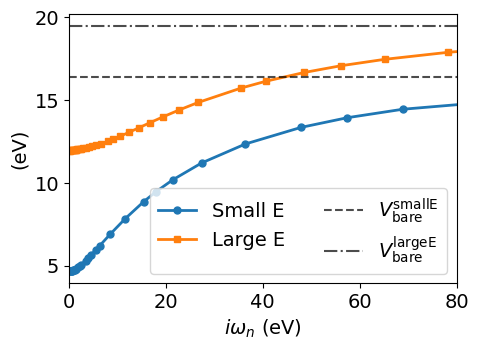

In [7]:
iaft2 = coqui.IAFT.from_coqui_chkpt("crpa_dp_100.mbpt.h5")
iw_mesh_pos2 = iaft2.wn_mesh(stats='b', positive_only=True) * np.pi / iaft2.beta

fig, ax = plt.subplots(1, figsize=(5,3.5), dpi=100)
ax.plot(iw_mesh_pos*HARTREE_EV, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='Small E')
ax.plot(iw_mesh_pos2*HARTREE_EV, (Vloc2[0,0,0,0]+Uloc2_iw[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='s', markersize=5, label='Large E')

ax.axhline(y=Vloc[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="--", linewidth=1.5, alpha=0.7, label='$V^{\mathrm{small E}}_{\mathrm{bare}}$')
ax.axhline(y=Vloc2[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="-.", linewidth=1.5, alpha=0.7, label='$V^{\mathrm{large E}}_{\mathrm{bare}}$')
ax.set_xlim(0, 80)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('$i\omega_{n}$ (eV)', fontsize=14)
ax.set_ylabel('(eV)', fontsize=14)
ax.legend(ncol=2, fontsize=14)

/mnt/home/cyeh/py_env/py311_mod2.4/lib/python3.11/site-packages/cvxpy/expressions/constants/constant.py:52: UserWarning: Initializing a Constant with a nested list is undefined behavior. Consider using a numpy array instead.
  warnings.warn(NESTED_LIST_WARNING)
/mnt/home/cyeh/py_env/py311_mod2.4/lib/python3.11/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


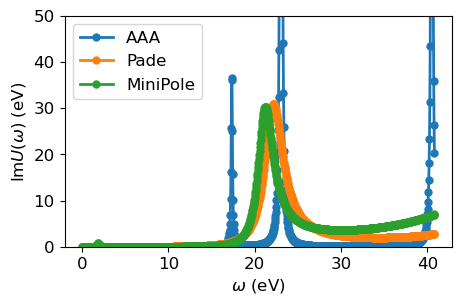

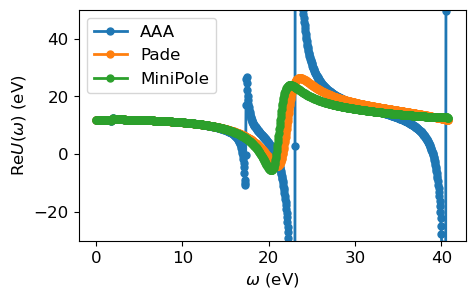

In [8]:
Uw_aaa, w_mesh_aaa = coqui.post_proc.aaa_adapol(Uloc2_iw[:,0,0,0,0], iaft2, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, Nfit=40, ph_sym=True)
Ufit2 = coqui.post_proc.aaa_adapol_imag(Uloc2_iw[:,0,0,0,0], iaft2, stats='boson', Nfit=40, ph_sym=True)
Uw_pade, w_mesh_pade = coqui.post_proc.pade(Ufit2, iaft2, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, Nfit=20, ph_sym=True)
Uw_minipole, w_mesh_minipole = coqui.post_proc.minipole(Ufit2, iaft2, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, tol=1e-7, ph_sym=True)

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(w_mesh_aaa.real * HARTREE_EV, -Uw_aaa.imag * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='AAA')
ax.plot(w_mesh_pade.real * HARTREE_EV, -Uw_pade.imag * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='Pade')
ax.plot(w_mesh_minipole.real * HARTREE_EV, -Uw_minipole.imag * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='MiniPole')
ax.set_ylim(0, 50)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$\omega$ (eV)', fontsize=12)
ax.set_ylabel('Im$U(\omega)$ (eV)', fontsize=12)
ax.legend(fontsize=12)
plt.show()

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(w_mesh_aaa.real * HARTREE_EV, (Vloc2[0,0,0,0]+Uw_aaa).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='AAA')
ax.plot(w_mesh_pade.real * HARTREE_EV, (Vloc2[0,0,0,0]+Uw_pade).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='Pade')
ax.plot(w_mesh_minipole.real * HARTREE_EV, (Vloc2[0,0,0,0]+Uw_minipole).real * HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label='MiniPole')
ax.set_ylim(-30, 50)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$\omega$ (eV)', fontsize=12)
ax.set_ylabel('Re$U(\omega)$ (eV)', fontsize=12)
ax.legend(fontsize=12)
plt.show()